# Figure S1-3 Supplements Reproduction

This notebook reproduces the supplementary figures for Figures S1-3  from the paper using pre-processed CSV data.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import string
from pathlib import Path

# --- Configuration ---
MODEL_COLORS = {
    "EEGNetv4": "#f4a582",
    "ATCNet": "#92c5de", 
    "ShallowConvNet": "#ca0020",
    "DeepConvNet": "#0571b0",
}

PARADIGMS_MASTER_LIST = {
    "MI": {
        "datasets": [
            {"dataset": "Yang2025", "name_for_plot": "MI (Yang2025)"},
            {"dataset": "Lee2019_MI", "name_for_plot": "MI (Lee2019)"},
            {"dataset": "BNCI2014_001", "name_for_plot": "MI (BNCI2014)"},
        ],
        "output_filename": "figs1a_reproduction.pdf",
    },
    "P300": {
        "datasets": [
            {"dataset": "BI2015a", "name_for_plot": "P300 (BI2015a)"},
            {"dataset": "Huebner2017", "name_for_plot": "P300 (Huebner2017)"},
            {"dataset": "Huebner2018", "name_for_plot": "P300 (Huebner2018)"},
        ],
        "output_filename": "figs1b_reproduction.pdf",
    },
    "SSVEP": {
        "datasets": [
            {"dataset": "Lee2019_SSVEP", "name_for_plot": "SSVEP (Lee2019)"},
            {"dataset": "Kalunga2016", "name_for_plot": "SSVEP (Kalunga2016)"},
            {"dataset": "MAMEM2", "name_for_plot": "SSVEP (MAMEM2)"},
        ],
        "output_filename": "figs1c_reproduction.pdf",
    },
}

DATASET_TRIAL_CUTOFFS = {
    "Yang2025": 600,
    "Lee2019_MI": 800,
    "BNCI2014_001": 250,
    "BI2015a": 1044,
    "Huebner2017": 400,
    "Huebner2018": 500,
    "Lee2019_SSVEP": 200,
    "Kalunga2016": 240,
    "MAMEM2": 300,
}

CONFIG_NAME_MAP = {
    "TL-ZS": "TL-ZS",
    "TL+CFT": "TL+CFT",
    "TL+UDA": "TL+UDA",
    "TL+UDA+CFT": "TL+UDA+CFT",
}

CONFIGS = {
    "CFT_vs_ZS-TL": {
        "ft_method": "TL+CFT",
        "zs_method": "TL-ZS",
        "name_for_plot_ft_part": "TL+CFT",
        "name_for_plot_zs_part": "TL-ZS",
        "col_idx_line": 0,
        "col_idx_scatter": 1,
        "column_title": f"{CONFIG_NAME_MAP['TL+CFT']} vs. {CONFIG_NAME_MAP['TL-ZS']}"
    },
    "CFT+UDA_vs_ZS-TL+UDA": {
        "ft_method": "TL+UDA+CFT",
        "zs_method": "TL+UDA",
        "name_for_plot_ft_part": "TL+UDA+CFT",
        "name_for_plot_zs_part": "TL+UDA",
        "col_idx_line": 2,
        "col_idx_scatter": 3,
        "column_title": f"{CONFIG_NAME_MAP['TL+UDA+CFT']}\nvs. {CONFIG_NAME_MAP['TL+UDA']}"
    },
}

FONTSIZE = 7

In [7]:
# Load data
data_dir = Path("figure_data")
time_series_df = pd.read_csv(data_dir / "fig1_supplements_time_series_data.csv")
scatter_df = pd.read_csv(data_dir / "fig1_supplements_scatter_data.csv")

print(f"Time series data shape: {time_series_df.shape}")
print(f"Scatter data shape: {scatter_df.shape}")
print(f"\nDatasets in time series: {sorted(time_series_df['dataset'].unique())}")
print(f"Methods in time series: {sorted(time_series_df['method'].unique())}")
print(f"Models in time series: {sorted(time_series_df['model'].unique())}")

Time series data shape: (55664, 7)
Scatter data shape: (1032, 8)

Datasets in time series: ['BI2015a', 'BNCI2014_001', 'Huebner2017', 'Huebner2018', 'Kalunga2016', 'Lee2019_MI', 'Lee2019_SSVEP', 'MAMEM2', 'Yang2025']
Methods in time series: ['TL+CFT', 'TL+UDA', 'TL+UDA+CFT', 'TL-ZS']
Models in time series: ['ATCNet', 'DeepConvNet', 'EEGNetv4', 'ShallowConvNet']


In [8]:
def plot_time_series(ax, df_ft, df_baseline, cutoff, show_xlabel=False, show_ylabel=False, show_legend=False):
    """Plot time series for a single panel."""
    
    for model in MODEL_COLORS.keys():
        color = MODEL_COLORS[model]
        
        # Plot Finetuned (solid line)
        ft_data = df_ft[df_ft['model'] == model].sort_values('trial_index')
        if not ft_data.empty:
            ax.plot(ft_data['trial_index'], ft_data['smoothed_accuracy'], 
                   color=color, linewidth=1.8, linestyle='-')
        
        # Plot Baseline (dotted line)
        baseline_data = df_baseline[df_baseline['model'] == model].sort_values('trial_index')
        if not baseline_data.empty:
            ax.plot(baseline_data['trial_index'], baseline_data['smoothed_accuracy'], 
                   color=color, linewidth=1.8, linestyle='dotted')
    
    # Formatting
    ax.set_xlim(0, cutoff)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_xlabel:
        ax.set_xlabel("Trial index", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("Smoothed mean acc.", fontsize=FONTSIZE)
    
    # Tick formatting
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.0f}'))
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    
    if show_legend:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='black', lw=1.8, label='Finetuned (CFT)', linestyle='-'),
            Line2D([0], [0], color='black', lw=1.8, label='Zero-shot (ZS)', linestyle='dotted')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=FONTSIZE, frameon=False)

In [9]:
def plot_scatter(ax, scatter_data, config_details, show_xlabel=False, show_ylabel=False, show_legend=False):
    """Plot scatter plot for a single panel."""
    x_metric_col = config_details['zs_method']
    y_metric_col = config_details['ft_method']
    data = scatter_data.dropna(subset=[x_metric_col, y_metric_col])
    
    handles = []
    for model in MODEL_COLORS.keys():
        model_data = data[data['model'] == model]
        if not model_data.empty:
            scatter = ax.scatter(model_data[x_metric_col], model_data[y_metric_col], 
                               color=MODEL_COLORS[model], s=6, alpha=1, 
                               edgecolors='k', linewidths=0.1, label=model)
            handles.append(scatter)
    
    ax.set_aspect('equal')
    
    # Set axis limits
    plot_min, plot_max = 0.0, 1.0
    if not data.empty:
        min_val_data = min(data[x_metric_col].min(), data[y_metric_col].min())
        max_val_data = max(data[x_metric_col].max(), data[y_metric_col].max())
        padding = 0.02
        plot_min = max(0.0, min_val_data - padding)
        plot_max = min(1.0, max_val_data + padding)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    
    # Add diagonal line and shading
    lims = ax.get_xlim()
    ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=0.7, zorder=0)
    x_coords = np.linspace(lims[0], lims[1], 100)
    ax.fill_between(x_coords, x_coords, lims[1], color='green', alpha=0.05, zorder=0)
    ax.fill_between(x_coords, lims[0], x_coords, color='red', alpha=0.05, zorder=0)
    
    # Formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_xlabel:
        ax.set_xlabel(f"{config_details['name_for_plot_zs_part']} mean acc.", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("Subject mean acc.", fontsize=FONTSIZE)
    
    # Tick formatting
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    
    if show_legend:
        ax.legend(handles=handles, fontsize=FONTSIZE, frameon=False, loc='best')


Generating Figure for Paradigm: MI -> figs1a_reproduction.pdf

Processing Dataset: MI (Yang2025)

Processing Dataset: MI (Lee2019)

Processing Dataset: MI (BNCI2014)


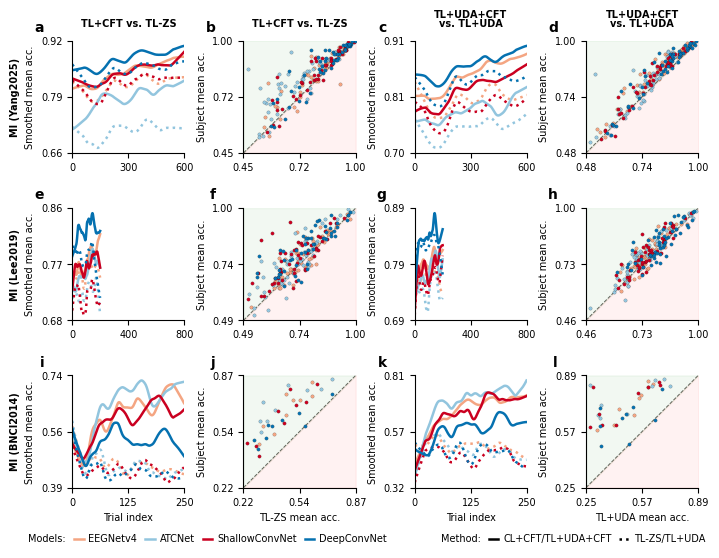


Generating Figure for Paradigm: P300 -> figs1b_reproduction.pdf

Processing Dataset: P300 (BI2015a)

Processing Dataset: P300 (Huebner2017)

Processing Dataset: P300 (Huebner2018)


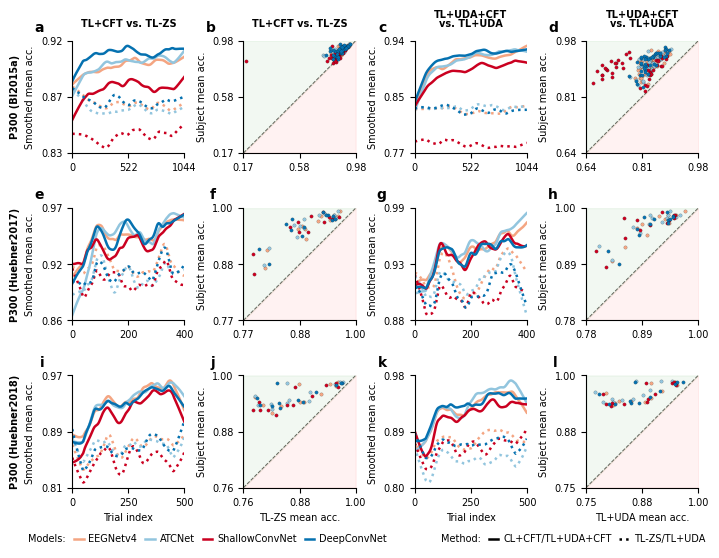


Generating Figure for Paradigm: SSVEP -> figs1c_reproduction.pdf

Processing Dataset: SSVEP (Lee2019)

Processing Dataset: SSVEP (Kalunga2016)

Processing Dataset: SSVEP (MAMEM2)


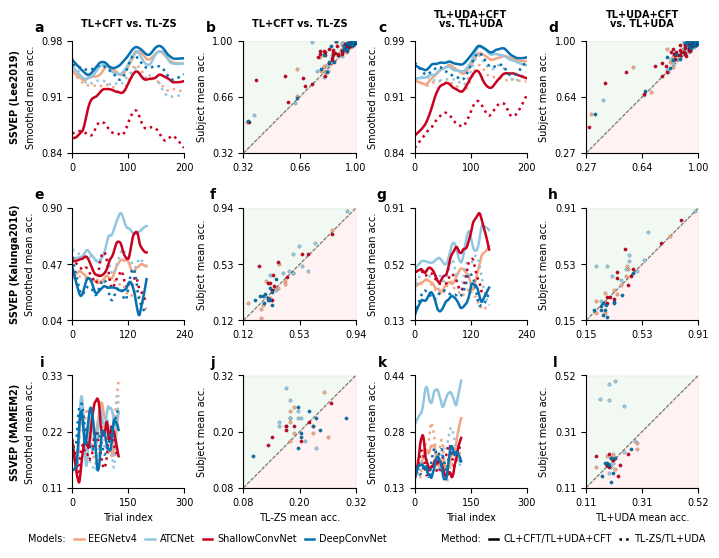


Script finished.


In [10]:
# --- Figure Layout and Style Configuration (from fig_1_supplements.py) ---
MAX_TOTAL_WIDTH_MM = 180.0
MARGIN_LEFT_CM = 1.7
MARGIN_RIGHT_CM = 0.4
MARGIN_TOP_CM = 1.1
MARGIN_BOTTOM_CM = 1.8
SPACING_HORIZONTAL_CM = 1.5
SPACING_VERTICAL_CM = 1.4

# --- Main Plotting Loop ---
for paradigm_key, group_details in PARADIGMS_MASTER_LIST.items():
    
    paradigm_datasets = group_details["datasets"]
    final_figure_path = Path(group_details["output_filename"])
    
    print(f"\n{'='*60}")
    print(f"Generating Figure for Paradigm: {paradigm_key} -> {final_figure_path}")
    print(f"{'='*60}")
    
    num_cols_fig = 4
    num_rows_fig = len(paradigm_datasets)

    # Calculate figure dimensions
    total_width_cm_fig = MAX_TOTAL_WIDTH_MM / 10.0
    effective_width_cm_fig = total_width_cm_fig - MARGIN_LEFT_CM - MARGIN_RIGHT_CM
    fig_panel_width_cm = (effective_width_cm_fig - (num_cols_fig - 1) * SPACING_HORIZONTAL_CM) / num_cols_fig
    fig_panel_height_cm = fig_panel_width_cm
    effective_height_cm_fig = num_rows_fig * fig_panel_height_cm + (num_rows_fig - 1) * SPACING_VERTICAL_CM
    total_height_cm_fig = effective_height_cm_fig + MARGIN_BOTTOM_CM + MARGIN_TOP_CM
    total_width_inches_fig = total_width_cm_fig / 2.54
    total_height_inches_fig = total_height_cm_fig / 2.54

    fig, main_axs = plt.subplots(
        num_rows_fig, num_cols_fig,
        figsize=(total_width_inches_fig, total_height_inches_fig),
        squeeze=False 
    )

    for row_idx, dataset_info in enumerate(paradigm_datasets):
        dataset_name = dataset_info["dataset"]
        plot_name = dataset_info["name_for_plot"]
        print(f"\nProcessing Dataset: {plot_name}")
        
        main_axs[row_idx, 0].text(-0.51, 0.5, plot_name, transform=main_axs[row_idx, 0].transAxes,
                                 ha='center', va='center', rotation='vertical', fontsize=FONTSIZE, fontweight='bold')
        
        df_dataset_ts = time_series_df[time_series_df['dataset'] == dataset_name]
        df_dataset_scatter = scatter_df[scatter_df['dataset'] == dataset_name]

        for config_key, config_vals in CONFIGS.items():
            if row_idx == 0:
                ax_title_line = main_axs[0, config_vals['col_idx_line']]
                ax_title_line.set_title(config_vals["column_title"], y=1.05, fontsize=FONTSIZE, weight='bold', ha='center', linespacing=0.9)

                ax_title_scatter = main_axs[0, config_vals['col_idx_scatter']]
                ax_title_scatter.set_title(config_vals["column_title"], y=1.05, fontsize=FONTSIZE, weight='bold', ha='center', linespacing=0.9)

            # Time-Series Plot
            ax_ts = main_axs[row_idx, config_vals['col_idx_line']]
            df_ft = df_dataset_ts[df_dataset_ts['method'] == config_vals['ft_method']]
            df_base = df_dataset_ts[df_dataset_ts['method'] == config_vals['zs_method']]
            plot_time_series(ax_ts, df_ft, df_base, 
                             cutoff=DATASET_TRIAL_CUTOFFS.get(dataset_name),
                             show_xlabel=(row_idx == num_rows_fig - 1), 
                             show_ylabel=True)
            
            # Scatter Plot
            ax_scatter = main_axs[row_idx, config_vals['col_idx_scatter']]
            plot_scatter(ax_scatter, df_dataset_scatter, config_vals, 
                         show_xlabel=(row_idx == num_rows_fig - 1),
                         show_ylabel=True)

    # Add panel labels
    panel_labels = string.ascii_lowercase
    label_idx = 0
    for ax_row in main_axs:
        for ax in ax_row:
            if label_idx < len(panel_labels):
                ax.text(-0.25, 1.18, panel_labels[label_idx], transform=ax.transAxes,
                        fontsize=10, fontweight='bold', va='top', ha='right')
                label_idx += 1

    # --- Figure Finalization and Legend ---
    left_norm = MARGIN_LEFT_CM / total_width_cm_fig
    right_norm = 1 - (MARGIN_RIGHT_CM / total_width_cm_fig)
    bottom_norm = MARGIN_BOTTOM_CM / total_height_cm_fig
    top_norm = 1 - (MARGIN_TOP_CM / total_height_cm_fig)
    fig_panel_width_cm_val = (total_width_cm_fig * (right_norm - left_norm) - (num_cols_fig - 1) * SPACING_HORIZONTAL_CM) / num_cols_fig
    wspace_val = SPACING_HORIZONTAL_CM / fig_panel_width_cm_val if fig_panel_width_cm_val > 0 else 0.1
    fig_panel_height_cm_val = (total_height_cm_fig * (top_norm - bottom_norm) - (num_rows_fig - 1) * SPACING_VERTICAL_CM) / num_rows_fig
    hspace_val = SPACING_VERTICAL_CM / fig_panel_height_cm_val if fig_panel_height_cm_val > 0 else 0.1

    from matplotlib.lines import Line2D
    model_elements = [Line2D([0], [0], color=color, label=model, linewidth=1.8) for model, color in MODEL_COLORS.items()]
    method_elements = [
        Line2D([0], [0], color='black', lw=1.8, label='CL+CFT/TL+UDA+CFT', linestyle='-'),
        Line2D([0], [0], color='black', lw=1.8, label='TL-ZS/TL+UDA', linestyle='dotted')
    ]
    models_title = mpatches.Patch(color='none', label='Models:')
    spacer = mpatches.Patch(color='none', label='   ')
    method_title = mpatches.Patch(color='none', label='Method:')
    all_handles = [models_title] + model_elements + [spacer] + [method_title] + method_elements

    fig.legend(handles=all_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), 
               ncol=len(all_handles), frameon=False, fontsize=FONTSIZE, 
               handletextpad=0.5, columnspacing=0.8, handlelength=1.0)

    fig.subplots_adjust(left=left_norm, right=right_norm, bottom=bottom_norm, top=top_norm, wspace=wspace_val, hspace=hspace_val)

    plt.savefig(final_figure_path, dpi=300)
    plt.show()
    plt.close(fig)

print("\nScript finished.")